In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
#X=pd.read_csv('nifty.csv')
#len(X)

In [3]:
def data1():
    X=pd.read_csv('tempcnnlstmcluster.csv')
    X = X.iloc[60:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [4]:
X=data1()
print(len(X))

2830


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\IIITNAGPUR\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


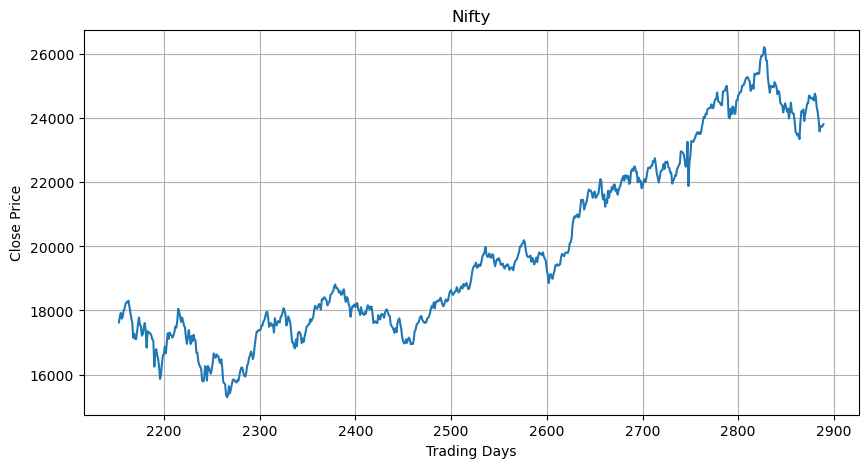

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
%pylab inline
fig = plt.figure()
ax=X.loc[2153:2889,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [6]:
len(X)

2830

In [7]:
X['Cluster'].value_counts()

Cluster
5.0    587
0.0    580
6.0    462
3.0    346
2.0    300
4.0    212
7.0    172
1.0    171
Name: count, dtype: int64

In [8]:
X.head()

,Unnamed: 0.1,Unnamed: 0,date,Close,High,Low,Open,Volume,weekday,month,...,cnnstate,state2d,state1d,state,Cluster,cashopen,cash,action,diff,quantity
60,60,60,18-06-2013,5813.600098,5863.399902,5804.299805,5841.899902,117500,0.25,6,...,0.0,0.0,0.0,0.0,7.0,0.0,0.0,,,
61,61,61,19-06-2013,5822.250000,5828.399902,5777.899902,5805.750000,115500,0.50,6,...,2.0,2.0,0.0,1.0,1.0,0.0,0.0,,,
62,62,62,20-06-2013,5655.899902,5755.000000,5645.649902,5754.149902,198400,0.75,6,...,0.0,0.0,0.0,0.0,7.0,0.0,0.0,,,
63,63,63,21-06-2013,5667.649902,5686.149902,5616.850098,5639.899902,182400,1.00,6,...,2.0,2.0,2.0,2.0,3.0,0.0,0.0,,,
64,64,64,24-06-2013,5590.250000,5640.000000,5566.250000,5638.049805,193500,0.00,6,...,1.0,4.0,5.0,5.0,0.0,0.0,0.0,,,


In [9]:
def getState(t):    
    t = int(t)
    return(X['Cluster'][t])  

In [ ]:
class Agent:
    def __init__(self):
           
        self.gamma = np.load('rl/gamma100.npy')
        self.Q = np.load('rl/Qtable100.npy')
        self.learning_rate=np.load('rl/learning_rate100.npy')
        self.epsilon = np.load('rl/epsilon100.npy')
        print(self.epsilon)
    def getAction(self,state):
        state = int(state)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [17]:
episode_count=1
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=2153
    data_length=2889
    state = getState(data_length_start)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    X.loc[2,'cashopen']=margin 
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
       
        elif action == 2:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=getState(t+1)
        #print("Next state:", next_state)  # Debugging
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n")
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
       
    
    m3=roi
    if m3>m2:
          m1=e
          m2=m3
        #To save model  
    if e%1==0:
            np.save('rl/test/Qtable'+ str(e)+str('.npy'), agent.Q)
            np.save('rl/test/epsilon'+ str(e)+str('.npy'), agent.epsilon)
            np.save('rl/test/gamma'+ str(e)+str('.npy'), agent.gamma)
            np.save('rl/test/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
            X.to_csv('csv1/AfterTest'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

0.009998671593271896
Episod 1/30

***********************

Profit is  82645.55571999916
Initial Capital is  173871.50389999998
Current Capital is  256517.05961999914
%ROI is  47.532547810440356
% Buy and Hold= 36.59627188627544
count 729
qtable [[0.00595914 0.00697666 0.0081748 ]
 [0.0039281  0.00731963 0.00737179]
 [0.0051694  0.00759368 0.00663508]
 [0.00597714 0.00754989 0.00949439]
 [0.00536944 0.00718349 0.01034735]
 [0.00594246 0.00741638 0.008139  ]
 [0.00643279 0.00827295 0.00792483]
 [0.00428572 0.0076518  0.00994079]]
epsilon 0.009998671593271896
--------------------------------
Episod 2/30

***********************

Profit is  101241.78615999946
Initial Capital is  173871.50389999998
Current Capital is  275113.29005999945
%ROI is  58.227934934195666
% Buy and Hold= 36.59627188627544
count 735
qtable [[0.00595914 0.00721476 0.00689374]
 [0.0039281  0.00717167 0.00721613]
 [0.0051694  0.0070873  0.00648463]
 [0.00597714 0.00754989 0.008722  ]
 [0.00536944 0.00718349 0.00934196]

In [ ]:
agent.Q

In [ ]:
%matplotlib inline
#%pylab inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-1,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()
#fig.savefig('baroda_close.png')